## Анализ работы моделей

> Предсказание оценки _(значения от 0 до 10)_

#### Выбор метрики для регрессии

В нашем случае метка _(оценка)_ — это целое число, а не вещественное. Однако регрессионные модели в основном будут выдавать вещественные метки, поэтому стоит оценивать и предсказания, и их 'округление' до целого числа.

Потенциально для нашей задачи могут подойти: 

- **MSE**
    - усредненная сумма квадратов ошибок
    - хорошо подходит, когда нельзя допускать большие ошибки
    - если в тестовой выборке присутствуют выбросы, то нам будет сложно объективно сравнить модели между собой: ошибки на выбросах будут маскировать различия в ошибках на нормальных объектах
- **RMSE**
    - корень из MSE
    - MSE с размерностью исходных данных
    - использовать RMSE для сравнения моделей на выборках с большим количеством выбросов может быть так же не хорошо
- **MAE**
    - сумма модулей ошибок
- **WAPE**
    - сумма модулей ошибок, деленная на сумму модулей истинных меток


Выбросов в целом быть не может, так как оценка всегда ставится от 0 до 10. Сделаем выбор в пользу MAE и RMSE

### Decision Tree

Для решающих деревьев используем уже предобработанные данные с заполнеными пропусками:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import optuna

In [2]:
df = pd.read_csv('encoded_data.csv')
df.head(3)

,student_id,program,education_level,academic_year,place_type,course,absence_status,discipline,module,exam_type,...,exam_type_prev,grade_prev,difficulty_prev,std_deviation_prev,students_responsed_ratio_prev,avg_grade_prev,min_prev,max_prev,target_grade,target_type
0,1,0.075439,0,2024,2.0,4,0,0.000000,1,0,...,0,6.0,3.776453,1.164422,0.833333,7.384615,4.0,10.0,7.0,0
1,1,0.075439,0,2024,2.0,4,0,0.000000,2,0,...,0,6.0,3.776453,1.164422,0.833333,7.647059,4.0,10.0,8.0,0
2,2,0.104502,0,2022,5.0,4,0,0.076667,1,0,...,0,6.5,3.628300,0.878089,0.791166,7.000000,7.0,7.0,7.0,0


In [3]:
X = df.drop(columns=['target_grade', 'target_type'])
y1 = df['target_grade']
y2 = df['target_type']

print(X.shape)
print(y1.shape)

(3360, 22)
(3360,)


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

Делим выборку в соотношении 5:65:30 - валидация / обучение / тестирование

In [5]:
X_, X_test, y1_, y1_test = train_test_split(X, y1, test_size=0.3, random_state=0)
X_train, X_val, y1_train, y1_val = train_test_split(X_, y1_, test_size=5/70)

In [6]:
tree_regressor = DecisionTreeRegressor(criterion='absolute_error', random_state=0)
tree_regressor = tree_regressor.fit(X_train, y1_train)

y1_pred_tree = tree_regressor.predict(X_test)
y1_pred_tree = np.round(y1_pred_tree) # оценки - целые числа

root_mean_squared_error(y1_test, y1_pred_tree)

2.542691050398726

Подберем гиперпараметры:

```py
class sklearn.tree.DecisionTreeRegressor(*, criterion='squared_error', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, ccp_alpha=0.0, monotonic_cst=None)[source]
```

**Параметры**:
- `criterion`: {“squared_error”, “friedman_mse”, “absolute_error”, “poisson”}, _default_=”squared_error”
    - функция для измерения качества разделения
        - “squared_error” для среднеквадратичной ошибки, которая равна уменьшению дисперсии в качестве критерия выбора функции и минимизирует потери в L2, используя среднее значение для каждого конечного узла
        - “friedman_mse” использует среднеквадратичную ошибку с оценкой Фридмана по улучшению для потенциальных разбиений
        - “absolute_error” для среднего абсолютного значения, минимизирует потерю L1, используя медиану каждого конечного узла
        - “poisson” использует уменьшение наполовину среднего отклонения Пуассона для нахождения разбиений

- `splitter`: {“best”, “random”}, _default_=”best”
    - cтратегия, используемая для выбора разделения на каждом узле

- `max_depth`: int, _default_=None
    - максимальная глубина дерева
        - если None, то узлы расширяются до тех пор, пока все листья не станут чистыми или пока все листья не будут содержать меньше чем min_samples_split выборок

- `min_samples_split`: int or float, _default_=2
    - минимальное количество выборок, необходимое для разделения внутреннего узла
        - если float, то min_samples_split - это дробь, а ceil(min_samples_split * n_samples) - минимальное количество выборок для каждого разделения

- `min_samples_leaf`: int or float, _default_=1 
    - минимальное количество выборок, необходимое для того, чтобы они находились в листе
    - точка разделения на любой глубине будет учитываться только в том случае, если она оставляет как минимум min_samples_leaf обучающих выборок в каждой левой и правой ветвях. _Это может привести к сглаживанию модели, особенно при регрессии_

- `min_weight_fraction_leaf`: float, _default_=0.0
    - минимальная взвешенная доля от общей суммы весов (всех входных выборок), которая должна находиться в конечном узле. 
    - выборки имеют одинаковый вес, если значение sample_weight не указано

- `max_features`: int, float or {“sqrt”, “log2”}, _default_=None
    - количество признаков, которые следует учитывать при поиске наилучшего варианта разделения

- `max_leaf_nodes`: int, _default_=None
    - дерево будет построено с max_leaf_nodes наилучшим образом
    - наилучшие узлы определяются как относительное уменьшение impurity
        - если None, то количество конечных узлов неограниченно

- `min_impurity_decrease`: float, _default_=0.0
    - узел будет разделен, если это разделение приведет к уменьшению impurity, превышающему или равному этому значению


In [7]:
def objective(trial):
    depth = trial.suggest_int('max_depth', 4, 50)
    leaf_nodes =  trial.suggest_int('max_leaf_nodes', 5, 100)
    samples_split = trial.suggest_int('min_samples_split', 2, 50)
    samples_leaf = trial.suggest_int('min_samples_leaf', 1, 100)
    
    tree = DecisionTreeRegressor(criterion='absolute_error', max_depth=depth, min_samples_split=samples_split, 
                                 min_samples_leaf=samples_leaf, max_leaf_nodes=leaf_nodes)
    tree.fit(X_train, y1_train)
    pred = tree.predict(X_val)
    pred = np.round(pred)
    
    return mean_absolute_error(y1_val, pred)


study = optuna.create_study(direction='minimize', study_name='DecisionTree_hyperparametrs')
optuna.logging.disable_default_handler()
study.optimize(objective, n_trials=100)

trial = study.best_trial
best_params = study.best_params

print("Best MAE: {}".format(trial.value))
print("Best hyperparameters: {}".format(trial.params))

[I 2026-06-08 16:28:19,047] A new study created in memory with name: DecisionTree_hyperparametrs


Best MAE: 1.255952380952381
Best hyperparameters: {'max_depth': 22, 'max_leaf_nodes': 41, 'min_samples_split': 18, 'min_samples_leaf': 37}


In [8]:
tree_regressor = DecisionTreeRegressor(**best_params, criterion='absolute_error')
tree_regressor.fit(X_train, y1_train)

y1_pred_tree = tree_regressor.predict(X_test)
y1_pred_tree_r = np.round(y1_pred_tree)

_Результаты на тестовой выборке (без округления предсказаний):_

In [9]:
test_rmse = root_mean_squared_error(y1_test, y1_pred_tree)
test_mae = mean_absolute_error(y1_test, y1_pred_tree)

print('RMSE:', test_rmse)
print('MAE: ', test_mae)

RMSE: 1.895849685957732
MAE:  1.2767857142857142


_Результаты на тестовой выборке (с округлением предсказаний):_

In [10]:
test_rmse_r = root_mean_squared_error(y1_test, y1_pred_tree_r)
test_mae_r = mean_absolute_error(y1_test, y1_pred_tree_r)

print('RMSE:', test_rmse_r)
print('MAE: ', test_mae_r)

RMSE: 1.895849685957732
MAE:  1.2767857142857142


Если сравнить результаты для тестовой и для обучающей выборок, то в целом переобучение не наблюдается

In [11]:
pred = np.round(tree_regressor.predict(X_train))
train_rmse_r = root_mean_squared_error(y1_train, pred)
train_mae_r = mean_absolute_error(y1_train, pred)

print('RMSE:', train_rmse_r, ' | delta =', abs(train_rmse_r - test_rmse_r))
print('MAE: ', train_mae_r, '  | delta =', abs(train_mae_r - test_mae_r))

RMSE: 1.719181805565101  | delta = 0.17666788039263115
MAE:  1.1341575091575091   | delta = 0.14262820512820507


### CatBoost 

In [12]:
from catboost import CatBoostRegressor, CatBoostClassifier, Pool

Библиотека CatBoost _(Categorical Boosting)_ предназначена для работы с категориальными данными, поэтому обрабатывать их предварительно не требуется. Заполним только пропуски:

In [13]:
df = pd.read_csv('total_laggs.csv', low_memory=False)
df.head(3)

,student_id,program,education_level,academic_year,place_type,course,absence_status,discipline,module,exam_type,...,exam_type_prev,grade_prev,difficulty_prev,std_deviation_prev,students_responsed_ratio_prev,avg_grade_prev,min_prev,max_prev,target_grade,target_type
0,1,Прикладная математика и информатика,Бакалавриат,2024,Бюджетные,4,\N,Веб-поиск и ранжирование,1,Первая сдача,...,NaN,NaN,NaN,NaN,NaN,7.384615,4.0,10.0,7.0,Первая сдача
1,1,Прикладная математика и информатика,Бакалавриат,2024,Бюджетные,4,\N,Правовая грамотность,2,Первая сдача,...,NaN,NaN,NaN,NaN,NaN,7.647059,4.0,10.0,8.0,Первая сдача
2,2,Прикладной анализ данных и искусственный интел...,Бакалавриат,2022,Коммерческие за счет средств вуза,4,\N,Дискретная математика,1,Первая сдача,...,NaN,NaN,NaN,NaN,NaN,7.000000,7.0,7.0,7.0,Первая сдача


In [14]:
def transform_data_for_catboost(path_to_data):
    data = pd.read_csv(path_to_data, low_memory=False)

    # difficulty_avg_score
    # берем среднее значение оценки сложности по конкретной дисциплине
    data['difficulty_avg_score'] = (data.groupby('discipline')['difficulty_avg_score'].transform(lambda x: x.fillna(x.mean())))
    data['difficulty_avg_score'] = (data['difficulty_avg_score'].fillna(data['difficulty_avg_score'].mean()))

    # std_deviation
    # разброс оценок тоже группируем по дисциплине и берем среднее
    data['std_deviation'] = (data.groupby('discipline')['std_deviation'].transform(lambda x: x.fillna(x.mean())))
    data['std_deviation'] = (data['std_deviation'].fillna(data['std_deviation'].mean()))
    
    # лаги:
    # тип экзамена: группируем по студентам и заполняем самым частым типом для каждого студента отдельно, если 
    # пропуски остались, заполняем самым частым типом для дисциплины, а потом самым частым типом глобально для всех студентов 
    data['exam_type_prev'] = (data.groupby('student_id')['exam_type_prev'].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)))
    data['exam_type_prev'] = (data.groupby('discipline')['exam_type_prev'].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)))
    data['exam_type_prev'] = (data['exam_type_prev'].fillna(data['exam_type_prev'].mode()[0]))

    # оценка: группируем по студентам и заполняем медианным значением для каждого студента отдельно, если 
    # пропуски остались, заполняем медианой по дисциплине, а потом уже глобальным медианным значением для всех студентов 
    data['grade_prev'] = (data.groupby('student_id')['grade_prev'].transform(lambda x: x.fillna(x.median())))
    data['grade_prev'] = (data.groupby('discipline')['grade_prev'].transform(lambda x: x.fillna(x.median())))
    data['grade_prev'] = (data['grade_prev'].fillna(data['grade_prev'].median()))

    # берем среднее значение оценки сложности по конкретной дисциплине
    data['difficulty_prev'] = (data.groupby('discipline')['difficulty_prev'].transform(lambda x: x.fillna(x.mean())))
    data['difficulty_prev'] = (data['difficulty_prev'].fillna(data['difficulty_prev'].mean()))

    # разброс оценок тоже группируем по дисциплине и берем среднее
    data['std_deviation_prev'] = (data.groupby('discipline')['std_deviation_prev'].transform(lambda x: x.fillna(x.mean())))
    data['std_deviation_prev'] = (data['std_deviation_prev'].fillna(data['std_deviation_prev'].mean()))

    # доля ответивших: сначала группируем программу + курс + учебный год
    data['students_responsed_ratio_prev'] = (data.groupby(['program', 'course', 'academic_year'])['students_responsed_ratio_prev'].transform(lambda x: x.fillna(x.mean())))
    # потом курс + учебный год
    data['students_responsed_ratio_prev'] = (data.groupby(['course', 'academic_year'])['students_responsed_ratio_prev'].transform(lambda x: x.fillna(x.mean())))
    # потом уже глобально 
    data['students_responsed_ratio_prev'] = (data['students_responsed_ratio_prev'].fillna(data['students_responsed_ratio_prev'].mean()))

    data['students_responsed_ratio'] = (data.groupby(['program', 'course', 'academic_year'])['students_responsed_ratio'].transform(lambda x: x.fillna(x.mean())))
    data['students_responsed_ratio'] = (data.groupby(['course', 'academic_year'])['students_responsed_ratio'].transform(lambda x: x.fillna(x.mean())))
    data['students_responsed_ratio'] = (data['students_responsed_ratio'].fillna(data['students_responsed_ratio'].mean()))
    
    return data

In [15]:
data = transform_data_for_catboost('total_laggs.csv')
data.head(3)

,student_id,program,education_level,academic_year,place_type,course,absence_status,discipline,module,exam_type,...,exam_type_prev,grade_prev,difficulty_prev,std_deviation_prev,students_responsed_ratio_prev,avg_grade_prev,min_prev,max_prev,target_grade,target_type
0,1,Прикладная математика и информатика,Бакалавриат,2024,Бюджетные,4,\N,Веб-поиск и ранжирование,1,Первая сдача,...,Первая сдача,7.0,4.458350,0.782715,0.833333,7.384615,4.0,10.0,7.0,Первая сдача
1,1,Прикладная математика и информатика,Бакалавриат,2024,Бюджетные,4,\N,Правовая грамотность,2,Первая сдача,...,Первая сдача,5.0,4.030758,0.840702,0.833333,7.647059,4.0,10.0,8.0,Первая сдача
2,2,Прикладной анализ данных и искусственный интел...,Бакалавриат,2022,Коммерческие за счет средств вуза,4,\N,Дискретная математика,1,Первая сдача,...,Первая сдача,6.5,3.614269,0.875573,0.788730,7.000000,7.0,7.0,7.0,Первая сдача


Аналогично поделим выборку в соотношении 5:65:30

In [16]:
X = data.drop(columns=['target_grade', 'target_type'])
y1 = data['target_grade']
y2 = data['target_type']

X_, X_test, y1_, y1_test = train_test_split(X, y1, test_size=0.3)
X_train, X_val, y1_train, y1_val = train_test_split(X_, y1_, test_size=5/70)

In [17]:
cat_features = [col for col in X.columns if X[col].dtype == 'str']

print(cat_features)

['program', 'education_level', 'place_type', 'absence_status', 'discipline', 'exam_type', 'exam_type_prev']


In [18]:
train_data = Pool(X_train, y1_train, cat_features)
catboost_model = CatBoostRegressor(iterations=100, loss_function='MAE' , verbose=False)

catboost_model.fit(train_data)
print(catboost_model.best_score_)

{'learn': {'MAE': 1.1996898969198315}}


Без подбора гиперпараметров результаты такие:

In [19]:
y1_pred_catboost = catboost_model.predict(X_test)
y1_pred_catboost = np.round(y1_pred_catboost) # оценки - целые числа

test_rmse = root_mean_squared_error(y1_test, y1_pred_catboost)
test_mae = mean_absolute_error(y1_test, y1_pred_catboost)

print('RMSE:', test_rmse)
print('MAE: ', test_mae)

RMSE: 1.6487128216441966
MAE:  1.1468253968253967


In [20]:
def objective(trial):
    iterations = trial.suggest_int('iterations', 100, 1000)
    lr = trial.suggest_float('learning_rate', 0, 1)
    depth = trial.suggest_int('depth', 1, 4)
    l2 = trial.suggest_float('l2_leaf_reg', 0, 100)
    leaf_min_size = trial.suggest_int('min_data_in_leaf', 10, 100)
    
    model = CatBoostRegressor(loss_function='MAE', iterations=iterations, learning_rate=lr, depth=depth, 
                              l2_leaf_reg=l2, min_data_in_leaf=leaf_min_size, verbose=False)
    model.fit(train_data)
    pred = model.predict(X_val)
    pred = np.round(pred)

    return root_mean_squared_error(y1_val, pred)


study = optuna.create_study(direction='minimize', study_name='CatBoost_hyperparametrs')
optuna.logging.disable_default_handler()
study.optimize(objective, n_trials=100)

trial = study.best_trial
best_params = study.best_params

print("Best RMSE: {}".format(trial.value))
print("Best hyperparameters: {}".format(trial.params))

Best RMSE: 1.7491494531696854
Best hyperparameters: {'iterations': 310, 'learning_rate': 0.027840399648168222, 'depth': 4, 'l2_leaf_reg': 3.92824763942005, 'min_data_in_leaf': 83}


Посмотрим на график обучения модели:

In [21]:
catboost_model = CatBoostRegressor(**best_params, loss_function='MAE', verbose=False)
catboost_model.fit(train_data, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

CatBoostRegressor(depth=4, iterations=310, l2_leaf_reg=3.92824763942005, learning_rate=0.027840399648168222, loss_function='MAE', min_data_in_leaf=83, verbose=False)

In [22]:
y1_pred_catboost = catboost_model.predict(X_test)
y1_pred_catboost_r = np.round(y1_pred_catboost)

_Результаты на тестовой выборке (без округления предсказаний):_

In [23]:
test_rmse = root_mean_squared_error(y1_test, y1_pred_catboost)
test_mae = mean_absolute_error(y1_test, y1_pred_catboost)

print('RMSE:', test_rmse)
print('MAE: ', test_mae)

RMSE: 1.5993776319637605
MAE:  1.1237401323536267


_Результаты на тестовой выборке (с округлением предсказаний):_

In [24]:
test_rmse_r = root_mean_squared_error(y1_test, y1_pred_catboost_r)
test_mae_r = mean_absolute_error(y1_test, y1_pred_catboost_r)

print('RMSE:', test_rmse_r)
print('MAE: ', test_mae_r)

RMSE: 1.635724682853211
MAE:  1.0942460317460319


Если сравнить с результатами на обучающей выборке, то переобучение не наблюдается

In [25]:
pred = np.round(catboost_model.predict(X_train))
train_rmse_r = root_mean_squared_error(y1_train, pred)
train_mae_r = mean_absolute_error(y1_train, pred)

print('RMSE:', train_rmse_r, ' | delta =', abs(train_rmse_r - test_rmse_r))
print('MAE: ', train_mae_r, '  | delta =', abs(train_mae_r - test_mae_r))

RMSE: 1.6892246308528223  | delta = 0.05349994799961122
MAE:  1.11996336996337   | delta = 0.025717338217338126


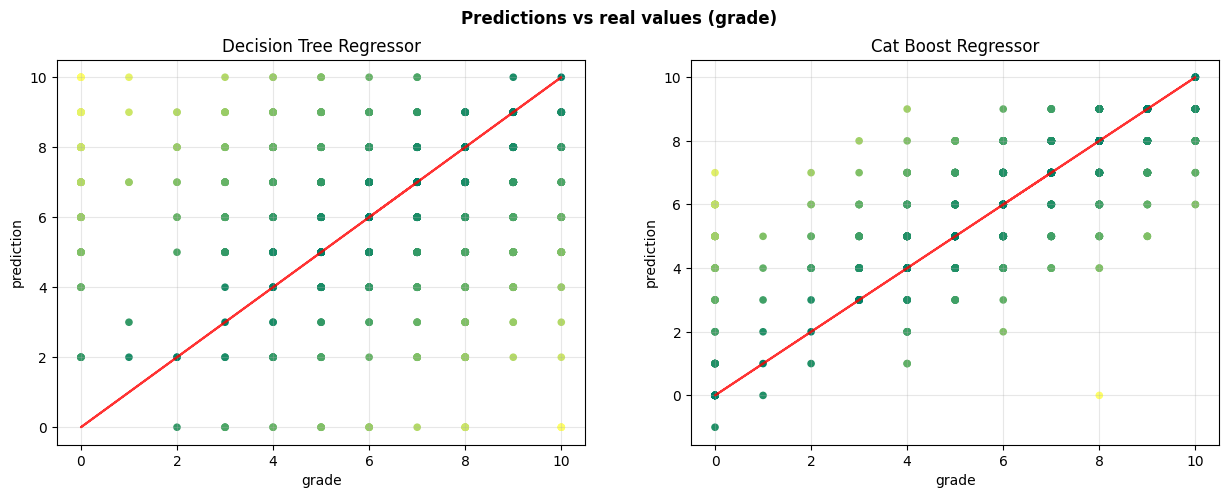

In [26]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Predictions vs real values (grade)', fontweight='bold')

axs[0].set_title('Decision Tree Regressor')
axs[0].scatter(y1_test, y1_pred_tree_r, c=np.abs(y1_test - y1_pred_tree_r), cmap='summer', s=20)
axs[0].plot(y1_test, y1_test, color='red', alpha=0.8)
axs[0].set_xlabel('grade')
axs[0].set_ylabel('prediction')
axs[0].grid(alpha=0.3)

axs[1].set_title('Cat Boost Regressor')
axs[1].scatter(y1_test, y1_pred_catboost_r, c=np.abs(y1_test - y1_pred_catboost_r), cmap='summer', s=20)
axs[1].plot(y1_test, y1_test, color='red', alpha=0.8)
axs[1].set_xlabel('grade')
axs[1].set_ylabel('prediction')
axs[1].grid(alpha=0.3)

_Видно, что предсказания (округленные) Cat Boost менее разбросаны и скоплены вдоль прямой y=x, поэтому лучше отдать предпочтение этой модели_

---

> Предсказание типа экзамена

Тут уже воспользуемся классификацией, всего возможно 4 типа экзамена

Можем заметить сильный дисбаланс классов:

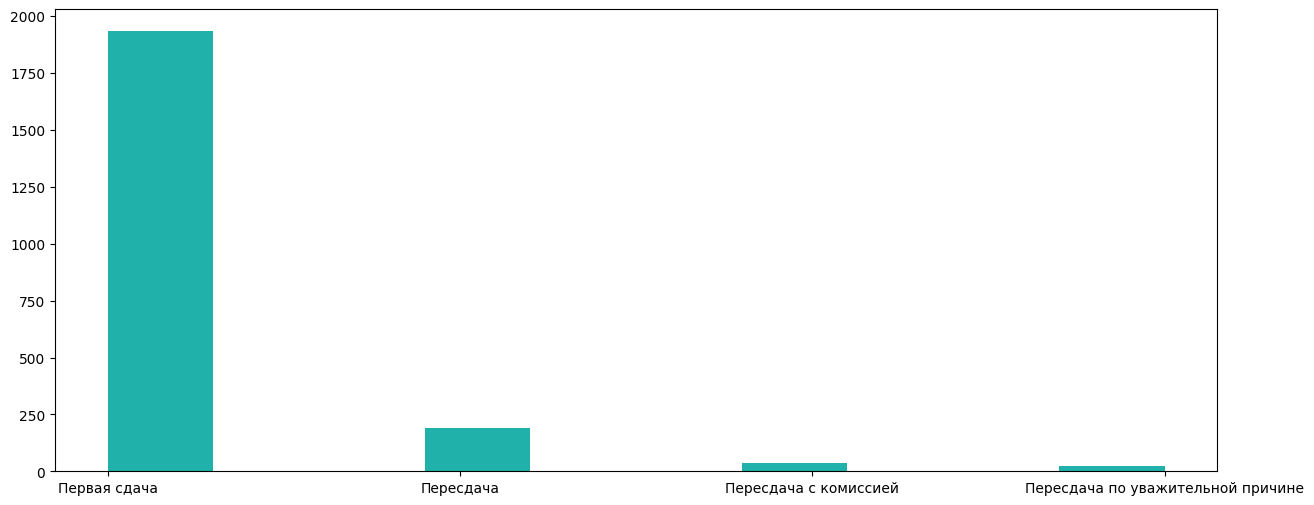

In [27]:
plt.figure(figsize=(15, 6))
plt.hist(X_train['exam_type'], color='lightseagreen')
plt.show()

### Выбор метрики для классификации

- **Accuracy**
    - $\frac{TP + TN}{TP + TN + FP + FN}$
    - доля объектов, для которых модель правильно предсказала класс

- **Precision**
    - $\frac{TP}{TP + FP}$
    - доля правильно предсказанных положительных объектов среди всех объектов, предсказанных положительным классом

- **Recall**
    - $\frac{TP}{TP + FN}$
    - доля правильно найденных положительных объектов среди всех объектов положительного класса

- **F1-measure**
    - $\frac{2}{1/\text{recall} + 1/\text{precision}}$
    - среднее гармоническое recall и precision
    - F1-мера предполагает одинаковую важность recall и precision, но если одна из этих метрик нам важнее - есть $F_{\beta}$-мера

Воспользуемся F1 мерой

> [multiclass classification](https://scikit-learn.org/stable/modules/model_evaluation.html#multiclass-and-multilabel-classification)

### Выбор типа агрегирования

- **micro**
    - метрики вычисляются глобально подсчетом общего количества TP, FN и FP результатов
    - _(большие классы будут "перевешивать" маленькие)_
- **macro**
    - метрики вычисляются для каждого класса отдельно, затем берется среднее арифметическое по классам
    - _(все классы будут равны, даже если их очень мало в данных)_
- **samples**
    - метрика вычисляется для каждого объекта, затем усредняется по всем объектам
- **weighted**
    - метрика вычисляется для каждого класса, затем берется среднее, взвешенное по числу реальных примеров этого класса 
    - _(учитывает дисбаланс классов, но не так сильно, как micro)_

Будем использовать macro-усреднение, так как нам важен каждый класс

### Decision Tree

In [28]:
from sklearn.metrics import f1_score

In [29]:
df = pd.read_csv('encoded_data.csv')

X = df.drop(columns=['target_grade', 'target_type'])
y2 = df['target_type']

In [30]:
X_, X_test, y2_, y2_test = train_test_split(X, y2, test_size=0.3)
X_train, X_val, y2_train, y2_val = train_test_split(X_, y2_, test_size=5/70)

In [31]:
clf = DecisionTreeClassifier()
clf.fit(X_train, y2_train)

y2_pred_clf = clf.predict(X_test)
print(f1_score(y2_test, y2_pred_clf, average='macro'))

0.7983720236391659


Настроим гиперпараметры:

In [32]:
def objective(trial):
    criterion = trial.suggest_categorical('criterion', ['gini', 'entropy', 'log_loss'])
    max_depth = trial.suggest_int('max_depth', 2, 50)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 50)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 200)

    tree_clf = DecisionTreeClassifier(criterion=criterion, max_depth=max_depth, 
                                  min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf)
    tree_clf.fit(X_train, y2_train)
    pred = tree_clf.predict(X_val)

    return f1_score(pred, y2_val, average='macro')

study = optuna.create_study(direction='maximize', study_name='DecisionTreeClassifier_hyperparametrs')
optuna.logging.disable_default_handler()
study.optimize(objective, n_trials=100)

trial = study.best_trial
best_params = study.best_params

print("Best F1-score: {}".format(trial.value))
print("Best hyperparameters: {}".format(trial.params))

Best F1-score: 0.8495167189132706
Best hyperparameters: {'criterion': 'entropy', 'max_depth': 17, 'min_samples_split': 32, 'min_samples_leaf': 34}


_Результат на тестовой выборке:_

In [33]:
clf_tree = DecisionTreeClassifier(**best_params)
clf_tree.fit(X_train, y2_train)

y2_pred_tree = clf_tree.predict(X_test)
test_f1 = f1_score(y2_test, y2_pred_tree, average='macro')

print(test_f1)

0.7700802407340352


Переобучение не наблюдается:

In [34]:
pred_train = clf_tree.predict(X_train)
train_f1 = f1_score(y2_train, pred_train, average='macro')

print(f'train F1-score: {train_f1} | delta = {abs(train_f1 - test_f1)}')

train F1-score: 0.8278471106114182 | delta = 0.057766869877383


In [35]:
imp_idx = np.argsort(clf_tree.feature_importances_)[::-1]
p, q = imp_idx[0], imp_idx[1] # 2 наиболее информативных признака
f, g = X_test.columns[p], X_test.columns[q] # их названия

In [36]:
f, g

('grade_10', 'exam_type')

Важность признаков (в дальнейшем можем удалить неинформативные признаки):

In [37]:
sorted(clf_tree.feature_importances_, reverse=True)

[np.float64(0.7708989090783811),
 np.float64(0.14996728857944036),
 np.float64(0.049904237224789705),
 np.float64(0.011251496312294615),
 np.float64(0.006493660754850598),
 np.float64(0.006247128633053581),
 np.float64(0.002478518108220322),
 np.float64(0.0014834214462506375),
 np.float64(0.0012753398627192735),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0)]

Посмотрим на поверхность решающего дерева:

In [38]:
from sklearn.inspection import DecisionBoundaryDisplay

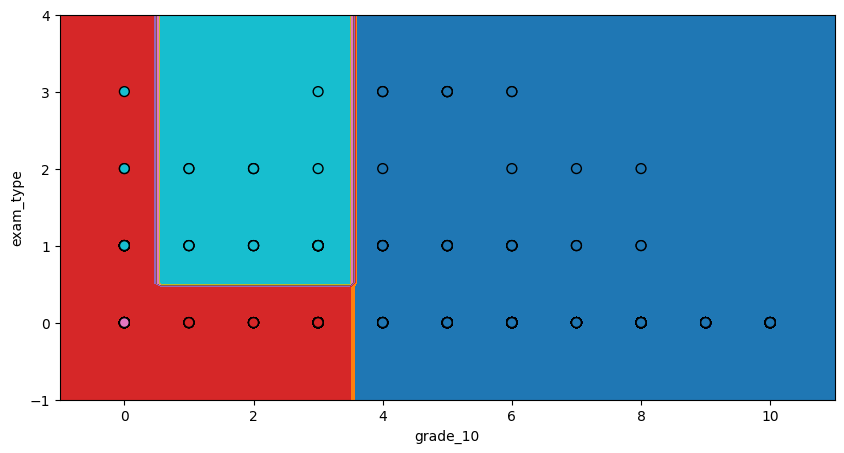

In [39]:
clf_ = DecisionTreeClassifier(**best_params)
clf_.fit(X_train[[f, g]], y2_train)

colors = ['mediumaquamarine', 'lightcoral', 'mediumpurple']

plt.figure(figsize=(10, 5))
DecisionBoundaryDisplay.from_estimator(
        clf_,
        X_test[[f, g]],
        response_method='predict',
        ax=plt.gca(),
        cmap='tab10'
)


labels = clf_tree.predict(X_test)
plt.scatter(X_test[f], X_test[g], cmap='tab10', c=labels, edgecolor='black', s=50)
plt.show()

### Cat Boost

In [40]:
data = transform_data_for_catboost('total_laggs.csv')

X = data.drop(columns=['target_grade', 'target_type'])
y2 = data['target_type']

X_, X_test, y2_, y2_test = train_test_split(X, y2, test_size=0.3)
X_train, X_val, y2_train, y2_val = train_test_split(X_, y2_, test_size=5/70)

In [41]:
cat_features = [col for col in X.columns if X[col].dtype == 'str']

In [42]:
train_data = Pool(X_train, y2_train, cat_features=cat_features)

clf_catboost = CatBoostClassifier(iterations=100, verbose=False)
clf_catboost.fit(train_data)

labels = clf_catboost.predict(X_test)
print(f1_score(y2_test, labels, average='macro'))

0.8619275548536088


Подберем гиперпараметры:

In [43]:
def objective(trial):
    iterations = trial.suggest_int('iterations', 100, 1000)
    lr = trial.suggest_float('learning_rate', 0, 0.5)
    depth = trial.suggest_int('depth', 1, 4)
    l2 = trial.suggest_float('l2_leaf_reg', 0, 100)
    leaf_min_size = trial.suggest_int('min_data_in_leaf', 10, 100)
    
    clf = CatBoostClassifier(iterations=iterations, learning_rate=lr, depth=depth, l2_leaf_reg=l2, min_data_in_leaf=leaf_min_size, verbose=False)
    clf.fit(train_data)
    pred = clf.predict(X_val)

    return f1_score(pred, y2_val, average='macro')


study = optuna.create_study(direction='maximize', study_name='CatBoostClassifier_hyperparametrs')
optuna.logging.disable_default_handler()
study.optimize(objective, n_trials=100)

trial = study.best_trial
best_params = study.best_params

print("Best F1-score: {}".format(trial.value))
print("Best hyperparameters: {}".format(trial.params))

Best F1-score: 0.9816760037348272
Best hyperparameters: {'iterations': 605, 'learning_rate': 0.22326776693682454, 'depth': 4, 'l2_leaf_reg': 2.7660256760741575, 'min_data_in_leaf': 37}


In [44]:
clf_catboost = CatBoostClassifier(**best_params, verbose=False)
clf_catboost.fit(train_data, plot=True)

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

CatBoostClassifier(depth=4, iterations=605, l2_leaf_reg=2.7660256760741575, learning_rate=0.22326776693682454, min_data_in_leaf=37, verbose=False)

_Результат на тестовой выборке:_

In [45]:
y2_pred_catboost = clf_catboost.predict(X_test)
test_f1 = f1_score(y2_test, y2_pred_catboost, average='macro')

print(test_f1)

0.8686783673103224


Переобучение не наблюдается:

In [46]:
pred_train = clf_catboost.predict(X_train)
train_f1 = f1_score(y2_train, pred_train, average='macro')

print(f'train F1-score: {train_f1} | delta = {abs(train_f1 - test_f1)}')

train F1-score: 0.9501874893260749 | delta = 0.08150912201575244


Для CatBoost-классификатора результаты лучше, поэтому отдадим преимущество этой модели